In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("../data/raw/Metro_Interstate_Traffic_Volume.csv")
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [14]:
df.shape

(48204, 9)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB


In [16]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [17]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [18]:
df = pd.read_csv("../data/raw/Metro_Interstate_Traffic_Volume.csv")
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [19]:
df["holiday"].value_counts(dropna=False)

holiday
NaN                          48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

In [20]:
df["date_time"] = pd.to_datetime(df["date_time"])
df["date_time"].dtype

dtype('<M8[us]')

In [21]:
df["date_time"].min(), df["date_time"].max()

(Timestamp('2012-10-02 09:00:00'), Timestamp('2018-09-30 23:00:00'))

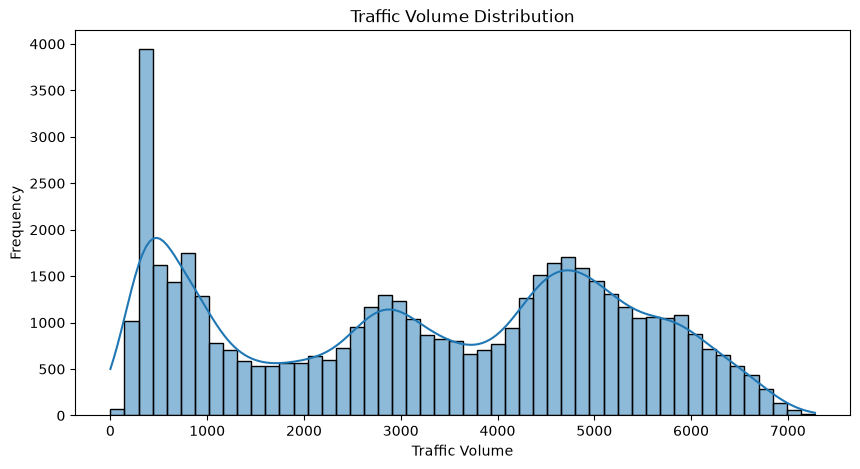

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df["traffic_volume"], bins=50, kde=True)
plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

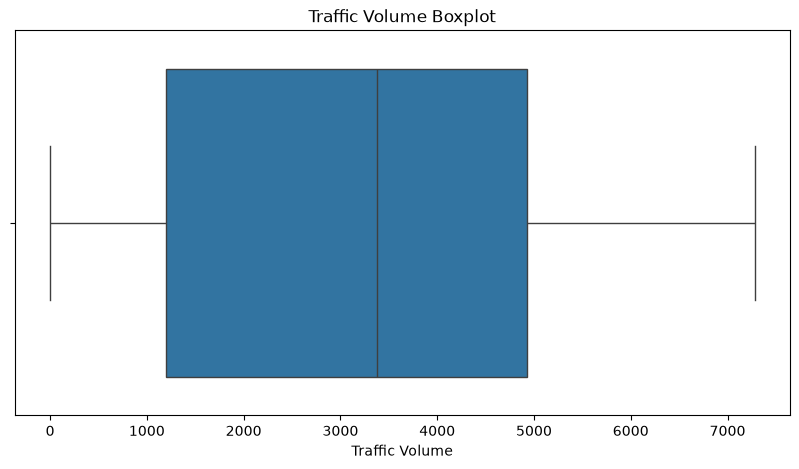

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["traffic_volume"])
plt.title("Traffic Volume Boxplot")
plt.xlabel("Traffic Volume")
plt.show()

In [24]:
df["traffic_volume"].describe()

count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

In [25]:
(df["traffic_volume"] == 0).sum()

np.int64(2)

In [26]:
(df["traffic_volume"] == 0).sum()

np.int64(2)

In [27]:
df[df["traffic_volume"] == 0][["date_time", "traffic_volume", "weather_main"]]

,date_time,traffic_volume,weather_main
25186,2016-07-23 18:00:00,0,Rain
25191,2016-07-23 23:00:00,0,Haze


In [28]:
df.loc[25180:25195, ["date_time", "traffic_volume", "weather_main"]]

,date_time,traffic_volume,weather_main
25180,2016-07-23 15:00:00,3,Rain
25181,2016-07-23 15:00:00,3,Thunderstorm
25182,2016-07-23 16:00:00,7,Rain
25183,2016-07-23 16:00:00,7,Mist
25184,2016-07-23 17:00:00,5,Rain
25185,2016-07-23 17:00:00,5,Mist
25186,2016-07-23 18:00:00,0,Rain
25187,2016-07-23 19:00:00,1,Clouds
25188,2016-07-23 20:00:00,5,Clouds
25189,2016-07-23 21:00:00,2,Clouds


In [29]:
df["date_time"].duplicated().sum()

np.int64(7629)

In [32]:
df[df["date_time"].duplicated(keep=False)].sort_values("date_time").head(20)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
178,NaN,281.25,0.0,0.0,99,Rain,light rain,2012-10-10 07:00:00,6793
179,NaN,281.25,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 07:00:00,6793
180,NaN,280.10,0.0,0.0,99,Rain,light rain,2012-10-10 08:00:00,6283
181,NaN,280.10,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 08:00:00,6283
182,NaN,279.61,0.0,0.0,99,Rain,light rain,2012-10-10 09:00:00,5680
183,NaN,279.61,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 09:00:00,5680
269,NaN,282.43,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 09:00:00,2685
270,NaN,282.43,0.0,0.0,57,Mist,mist,2012-10-14 09:00:00,2685
271,NaN,282.43,0.0,0.0,57,Haze,haze,2012-10-14 09:00:00,2685
272,NaN,282.33,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 10:00:00,3370


In [33]:
df.duplicated().sum()

np.int64(17)

In [34]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [35]:
df["holiday"].value_counts(dropna=False)

holiday
NaN                          48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

In [36]:
df["holiday"].isna().sum(), df["holiday"].notna().sum()

(np.int64(48143), np.int64(61))

In [37]:
df[df["date_time"].duplicated(keep=False)].sort_values("date_time").head(20)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
178,NaN,281.25,0.0,0.0,99,Rain,light rain,2012-10-10 07:00:00,6793
179,NaN,281.25,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 07:00:00,6793
180,NaN,280.10,0.0,0.0,99,Rain,light rain,2012-10-10 08:00:00,6283
181,NaN,280.10,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 08:00:00,6283
182,NaN,279.61,0.0,0.0,99,Rain,light rain,2012-10-10 09:00:00,5680
183,NaN,279.61,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 09:00:00,5680
269,NaN,282.43,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 09:00:00,2685
270,NaN,282.43,0.0,0.0,57,Mist,mist,2012-10-14 09:00:00,2685
271,NaN,282.43,0.0,0.0,57,Haze,haze,2012-10-14 09:00:00,2685
272,NaN,282.33,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 10:00:00,3370


In [38]:
df.duplicated().sum()

np.int64(17)